In [1]:
import mne
import openneuro
import pandas as pd
import numpy as np
np.set_printoptions(threshold=np.inf)
np.set_printoptions(linewidth=np.inf)
from mne_bids import (
    BIDSPath,
    find_matching_paths,
    get_entity_vals,
    make_report,
    print_dir_tree,
    read_raw_bids,
	write_raw_bids
)

In [2]:
def _channel_mapping(channel_list):
	new_list = []

	for channel in channel_list:
		if channel == "FP1":
			new_list.append("Fp1")
		elif channel == "FP2":
			new_list.append("Fp2")
		elif channel == "CZ":
			new_list.append("Cz")
		else:
			new_list.append(channel)
	return new_list


In [3]:
# From https://github.com/braindecode/braindecode/blob/master/braindecode/datasets/tuh.py
def _rename_channels(raw):
	"""
	Renames the EEG channels using mne conventions and sets their type to 'eeg'.

	See https://isip.piconepress.com/publications/reports/2020/tuh_eeg/electrodes/
	"""
	# remove ref suffix and prefix:
	# TODO: replace with removesuffix and removeprefix when 3.8 is dropped
	mapping_strip = {
		c: c.replace("-REF", "").replace("-LE", "").replace("EEG ", "")
		for c in raw.ch_names
	}
	raw.rename_channels(mapping_strip)

	montage1005 = mne.channels.make_standard_montage("standard_1005")
	mapping_eeg_names = {
		c.upper(): c for c in montage1005.ch_names if c.upper() in raw.ch_names
	}

	# Set channels whose type could not be inferred (defaulted to "eeg") to "misc":
	non_eeg_names = [c for c in raw.ch_names if c not in mapping_eeg_names]
	if non_eeg_names:
		non_eeg_types = raw.get_channel_types(picks=non_eeg_names)
		mapping_non_eeg_types = {
			c: "misc" for c, t in zip(non_eeg_names, non_eeg_types) if t == "eeg"
		}
		if mapping_non_eeg_types:
			raw.set_channel_types(mapping_non_eeg_types)

	if mapping_eeg_names:
		# Set 1005 channels type to "eeg":
		raw.set_channel_types(
			{c: "eeg" for c in mapping_eeg_names}, on_unit_change="ignore"
		)
		# Fix capitalized EEG channel names:
		raw.rename_channels(mapping_eeg_names)

In [ ]:
openneuro.download(dataset="ds005505", target_dir="SampleData/HBN", include=["sub-NDARAC904DMU", "sub-NDARAG143ARJ", "sub-NDARAM704GKZ"])

In [4]:
TUH_patient = mne.io.read_raw_edf('SampleData/TUH/aaaaaaac_s001_t000.edf', preload=False)
_rename_channels(TUH_patient)
print(TUH_patient.info.ch_names)
TUH_patient.info["line_freq"] = 50
annotations_df = pd.read_csv('SampleData/TUH/aaaaaaac_s001_t000.csv', delimiter=',', comment='#')

onset = annotations_df['start_time']
duration = annotations_df['stop_time'] - annotations_df['start_time']
description = annotations_df['label']
ch_names = [_channel_mapping(x.split("-")) for x in annotations_df['channel'].values.tolist()]

global_annotations_df = pd.read_csv('SampleData/TUH/aaaaaaac_s001_t000.csv_bi', delimiter=',', comment='#')

onset = pd.concat([onset, global_annotations_df['start_time']])
duration = pd.concat([duration, global_annotations_df['stop_time'] - global_annotations_df['start_time']])
description = pd.concat([description, global_annotations_df['label']])
global_channel_names = [[] for x in global_annotations_df['channel'].values.tolist()]
ch_names = ch_names + global_channel_names

annotations = mne.Annotations(onset=onset, duration=duration, description=description, ch_names=ch_names)

TUH_patient.set_annotations(annotations)
montage = mne.channels.make_standard_montage("standard_1005")
TUH_patient.set_montage(montage, on_missing="ignore")
for channel in TUH_patient.info["chs"]:
	print(channel['loc'])

Extracting EDF parameters from /mnt/batch/tasks/shared/LS_root/mounts/clusters/mchen439-e8ads-v5/code/Users/mchen439/EEG-Foundation-Model/SampleData/TUH/aaaaaaac_s001_t000.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'A1', 'A2', 'P3', 'P4', 'O1', 'O2', 'F7', 'F8', 'T3', 'T4', 'T5', 'T6', 'Fz', 'Cz', 'Pz', 'Oz', 'PG1', 'PG2', 'EKG', 'SP2', 'SP1', 'RLC', 'LUC', '30', 'T1', 'T2', 'PHOTIC PH']


/tmp/ipykernel_4161/1918410036.py:29: RuntimeWarning: The unit for channel(s) 30, EKG, LUC, PG1, PG2, PHOTIC PH, RLC, SP1, SP2, T1, T2 has changed from V to NA.
  raw.set_channel_types(mapping_non_eeg_types)


[-0.03090259  0.11458518  0.02786657  0.          0.          0.                 nan         nan         nan         nan         nan         nan]
[0.0284095  0.11534631 0.02772126 0.         0.         0.                nan        nan        nan        nan        nan        nan]
[-0.05180904  0.0866879   0.07871409  0.          0.          0.                 nan         nan         nan         nan         nan         nan]
[0.05027428 0.08743839 0.07727065 0.         0.         0.                nan        nan        nan        nan        nan        nan]
[-0.06714872  0.02335823  0.10451068  0.          0.          0.                 nan         nan         nan         nan         nan         nan]
[0.06532888 0.0235731  0.10369243 0.         0.         0.                nan        nan        nan        nan        nan        nan]
[-0.08794078  0.00260136 -0.02686454  0.          0.          0.                 nan         nan         nan         nan         nan         nan]
[ 0.08392806  

In [ ]:
bids_path = BIDSPath(subject="aaaaaaac", task="Rest", root="SampleData/TUH-BIDS")
write_raw_bids(TUH_patient, bids_path, overwrite=True)

In [12]:
hbn_bids_path = BIDSPath(root="SampleData/HBN", session=None, datatype="eeg")
hbn_bids_path = hbn_bids_path.update(subject="NDARAC904DMU", task="RestingState", suffix="eeg")
HBN_patient = read_raw_bids(bids_path=hbn_bids_path, verbose=True)

/tmp/ipykernel_4161/2368780825.py:3: RuntimeWarning: Data will be preloaded. preload=False or a string preload is not supported when the data is stored in the .set file
  HBN_patient = read_raw_bids(bids_path=hbn_bids_path, verbose=True)


Reading events from SampleData/HBN/sub-NDARAC904DMU/eeg/sub-NDARAC904DMU_task-RestingState_events.tsv.
Reading channel info from SampleData/HBN/sub-NDARAC904DMU/eeg/sub-NDARAC904DMU_task-RestingState_channels.tsv.
Reading electrode coords from SampleData/HBN/sub-NDARAC904DMU/eeg/sub-NDARAC904DMU_task-RestingState_electrodes.tsv.


/tmp/ipykernel_4161/2368780825.py:3: RuntimeWarning: Unable to map the following column(s) to to MNE:
release_number: R1
ehq_total: 71.17
commercial_use: Yes
full_pheno: Yes
p_factor: -0.603
attention: -0.446
internalizing: 1.248
externalizing: 0.325
RestingState: available
DespicableMe: available
FunwithFractals: available
ThePresent: available
DiaryOfAWimpyKid: available
contrastChangeDetection_1: available
contrastChangeDetection_2: available
contrastChangeDetection_3: available
surroundSupp_1: available
surroundSupp_2: available
seqLearning6target: unavailable
seqLearning8target: available
symbolSearch: available
  HBN_patient = read_raw_bids(bids_path=hbn_bids_path, verbose=True)


In [ ]:
tuh_bids_path = BIDSPath(root="SampleData/TUH-BIDS", session=None, datatype="eeg")
tuh_bids_path = tuh_bids_path.update(subject="aaaaaaac", task="Rest", suffix="eeg")
TUH_patient = read_raw_bids(bids_path=tuh_bids_path, verbose=True)

In [ ]:
TUH_patient.load_data()
TUH_patient.set_eeg_reference(ref_channels=['A1', 'A2'])
print(TUH_patient.info)
TUH_patient.set_eeg_reference(ref_channels=['Cz'])

In [13]:
# See Page 234 of /https://psych.colgate.edu/~bchansen/EGI_GES_INFO/NetStation_Acquisition_Technical_Manual.pdf
electrode_map = {
	'Fp1': 'E22',
	'Fp2': 'E14',
	'F7': 'E34',
	'F3': 'E25',
	'Fz': 'E11',
	'F4': 'E124',
	'F8': 'E122',
	'T3': 'E46',
	'C3': 'E37',
	'Cz': 'Cz',
	'C4': 'E105',
	'T4': 'E109',
	'T5': 'E59',
	'P3': 'E53',
	'Pz': 'E62',
	'P4': 'E87',
	'T6': 'E92',
	'O1': 'E72',
	'O2': 'E77',
	'A1': 'E49',
	'A2': 'E114'
}

electrode_map2 = {
	'Fp1': 'E22',
	'Fp2': 'E9',
	'F7': 'E33',
	'F3': 'E24',
	'Fz': 'E11',
	'F4': 'E124',
	'F8': 'E122',
	'T3': 'E45',
	'C3': 'E36',
	'Cz': 'Cz',
	'C4': 'E104',
	'T4': 'E108',
	'T5': 'E58',
	'P3': 'E52',
	'Pz': 'E62',
	'P4': 'E92',
	'T6': 'E96',
	'O1': 'E70',
	'O2': 'E83',
	'A1': 'E49',
	'A2': 'E113'
}

HBN_ELECTRODE_MAP = {
	'Fp1': 'E37',
	'Fp2': 'E18',
	'F7': 'E47',
	'F3': 'E36',
	'Fz': 'E21',
	'F4': 'E224',
	'F8': 'E2',
	'T3': 'E69',
	'C3': 'E59',
	'Cz': 'Cz',
	'C4': 'E183',
	'T4': 'E202',
	'T5': 'E96',
	'P3': 'E87',
	'Pz': 'E101',
	'P4': 'E153',
	'T6': 'E270',
	'O1': 'E116',
	'O2': 'E150',
	'A1': 'E49',
	'A2': 'E113'
}

electrodes = [f'E{i}' for i in range(1, 129)]
to_drop = [electrode for electrode in electrodes if electrode not in HBN_ELECTRODE_MAP.values()]

In [14]:
#TUH_patient = TUH_patient.filter(l_freq=0, h_freq=40)
HBN_patient.drop_channels(to_drop)
HBN_patient = HBN_patient.filter(l_freq=0, h_freq=40)

Filtering raw data in 1 contiguous segment
Setting up low-pass filter at 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 165 samples (0.330 s)



In [5]:
TUH_patient.info

NameError: name 'TUH_patient' is not defined

In [6]:
HBN_patient.info

<Info | 10 non-empty values
 bads: []
 ch_names: E1, E2, E3, E4, E5, E6, E7, E8, E9, E10, E11, E12, E13, E14, ...
 chs: 129 EEG
 custom_ref_applied: False
 dig: 129 items (129 EEG)
 highpass: 0.0 Hz
 line_freq: 60.0
 lowpass: 250.0 Hz
 meas_date: unspecified
 nchan: 129
 projs: []
 sfreq: 500.0 Hz
 subject_info: 2 items (dict)
>

In [ ]:
TUH_patient.get_montage().plot(show_names=True)

In [ ]:
for channel in HBN_patient.info["chs"]:
	print(channel)

/tmp/ipykernel_4161/3267157450.py:4: RuntimeWarning: Fiducial point nasion not found, assuming identity unknown to head transformation
  hbn_montage.plot(show_names=True, sphere=0.0095)


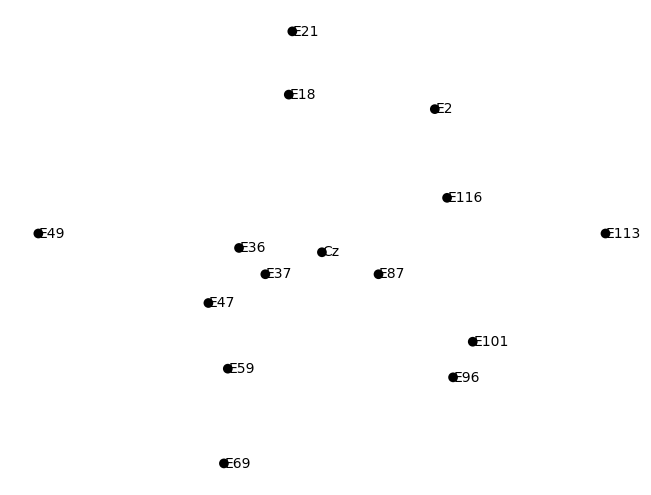

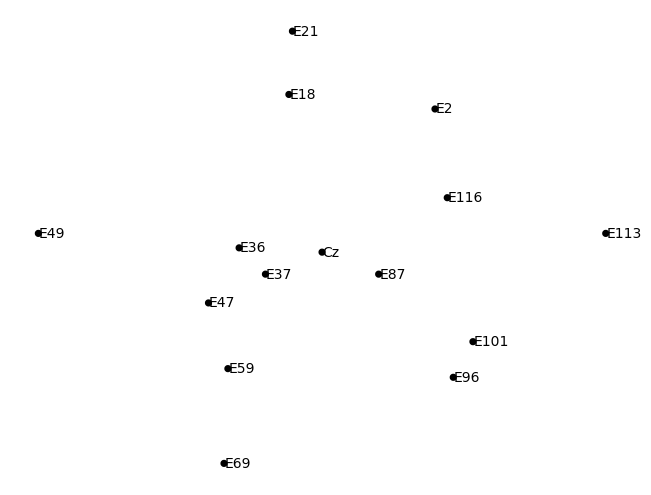

In [15]:
transformation_matrix = np.asarray([[0, -100, 0, 0], [100, 0, 0, 0], [0, 0, 100, 0], [0, 0, 0, 100]])
hbn_montage = HBN_patient.get_montage()
hbn_montage.apply_trans(mne.transforms.Transform(fro='ctf_head', to='unknown', trans=transformation_matrix))
hbn_montage.plot(show_names=True, sphere=0.0095)

Using matplotlib as 2D backend.


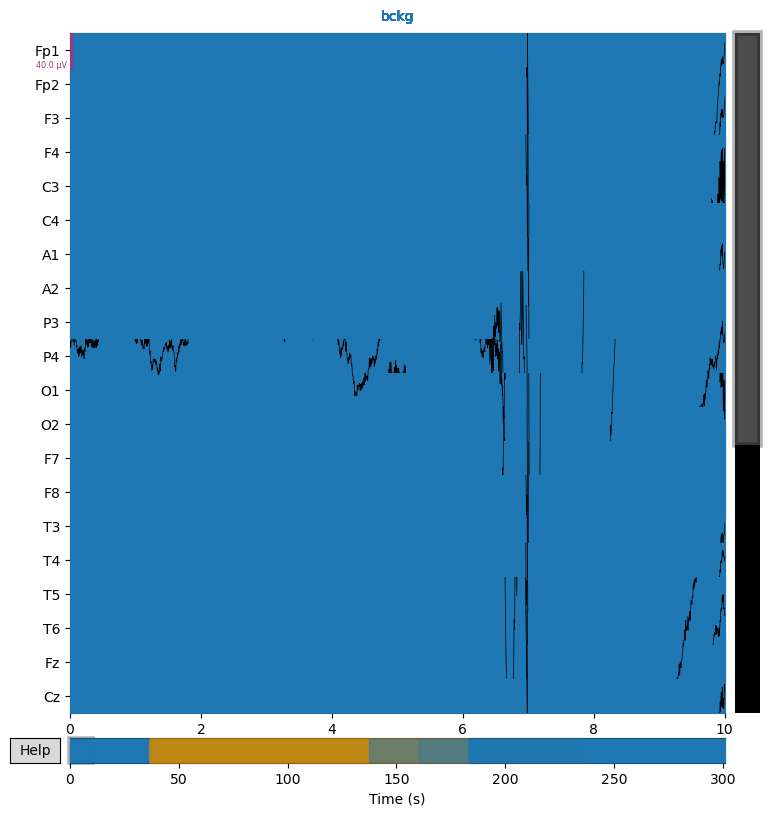

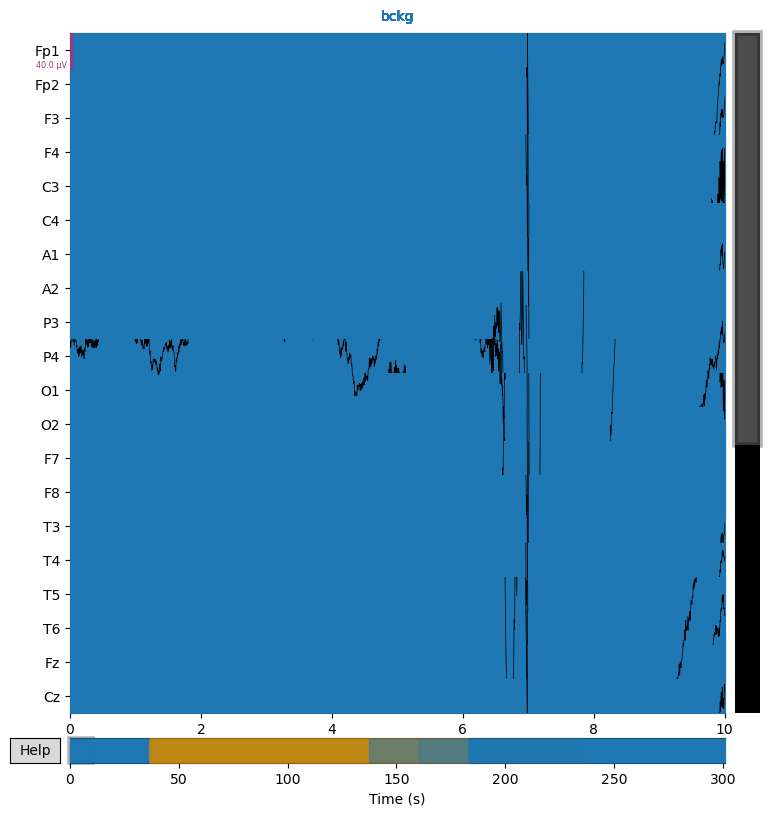

In [9]:
mne.viz.set_browser_backend("matplotlib")
TUH_patient.plot()

In [ ]:
print(TUH_patient.annotations)

In [9]:
TUH_patient = mne.io.read_raw_edf('/home/azureuser/mycontainer/edf/000/aaaaaaaa/s001_2015/01_tcp_ar/aaaaaaaa_s001_t000.edf', preload=False)
TUH_patient.info

Extracting EDF parameters from /home/azureuser/mycontainer/edf/000/aaaaaaaa/s001_2015/01_tcp_ar/aaaaaaaa_s001_t000.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...


<Info | 8 non-empty values
 bads: []
 ch_names: EEG FP1-REF, EEG FP2-REF, EEG F3-REF, EEG F4-REF, EEG C3-REF, ...
 chs: 31 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 128.0 Hz
 meas_date: 2015-01-01 00:00:00 UTC
 nchan: 31
 projs: []
 sfreq: 256.0 Hz
 subject_info: 3 items (dict)
>

In [13]:
print(TUH_patient.info['meas_date'])
print(TUH_patient.annotations)
print(TUH_patient.get_montage())
print(TUH_patient._raw_extras[0]['age'])

2015-01-01 00:00:00+00:00
<Annotations | 0 segments>
None


KeyError: 'age'

In [14]:
from edfio import read_edf


edf = read_edf('/home/azureuser/mycontainer/edf/000/aaaaaaaa/s001_2015/01_tcp_ar/aaaaaaaa_s001_t000.edf')


In [18]:
print(edf.patient)
print(edf.recording)

'aaaaaaaa M 01-JAN-0000 aaaaaaaa Age:37'
Recording(startdate=datetime.date(2015, 1, 1), hospital_administration_code='aaaaaaaa_s001', investigator_technician_code='XXX', equipment_code='#', additional=())


In [1]:
import os
from tqdm import tqdm
import mne
from mne_bids import BIDSPath, read_raw_bids, write_raw_bids
import pandas as pd
import numpy as np
import os, argparse
from pathlib import Path
from tqdm import tqdm
from concurrent.futures import ProcessPoolExecutor, as_completed
import warnings


CHANNELS_TO_KEEP = {
	"Fp1",
	"Fp2",
	"F3",
	"F4",
	"C3",
	"C4",
	"A1",
	"A2",
	"P3",
	"P4",
	"O1",
	"O2",
	"F7",
	"F8",
	"T3",
	"T4",
	"T5",
	"T6",
	"Fz",
	"Cz",
	"Pz",
}

print(len(CHANNELS_TO_KEEP))
def process_file(args, subfolder, subject, session, montage_layout, file_token, failed_files):
        if file_token.endswith(".edf"):
            _convertEDFtoBIDS(args, subfolder, subject, session, montage_layout, file_token, failed_files)
        else:
            print("-----------------------------------", file_token)

def convertTUHtoBIDS(args):
	'''
	Converts TUH EEG data to BIDS format.
	'''

	# Collect all files to be processed
	files_to_process = []
	for subfolder in tqdm(os.listdir(args.input_dir)):
		for subject in os.listdir(os.path.join(args.input_dir, subfolder)):
			subject_dir = os.path.join(args.input_dir, subfolder, subject)
			for session in os.listdir(subject_dir):
				for montage_layout in os.listdir(os.path.join(subject_dir, session)):
					for file_token in os.listdir(os.path.join(subject_dir, session, montage_layout)):
						files_to_process.append((args, subfolder, subject, session, montage_layout, file_token))
                            
	return files_to_process
                            
    
def _convertEDFtoBIDS(args, subfolder, subject, session, montage_layout, file_token, failed_files):
	'''
	Converts an EDF file to BIDS format.
	'''
	filepath = os.path.join(args.input_dir, subfolder, subject, session, montage_layout, file_token)
	raw = mne.io.read_raw_edf(filepath, preload=False, verbose=False)
	_rename_channels(raw)

	to_drop = [ch for ch in raw.ch_names if ch not in CHANNELS_TO_KEEP]

	try:
		raw.drop_channels(to_drop)
	except ValueError as e:
		failed_files.append((subject, session, montage_layout, file_token))
		return

	'''
	BIDS Format requires line frequency to be specified.
	Line frequency is the frequency of the power line in the country where the data was recorded.
	For the United States, the line frequency is (typically) 60 Hz.	
	'''
	raw.info["line_freq"] = 60
	raw.set_montage("standard_1005", on_missing="ignore")
	try: 
		assert len(raw.info["ch_names"]) == 21 or len(raw.info["ch_names"]) == 19, f"Expected 19 or 21 channels, got {len(raw.info['ch_names'])} channels."
	except AssertionError as e:
		failed_files.append((subject, session, montage_layout, file_token))
		return
		
	'''
	bids_path = BIDSPath(subject=subject, session=session.replace("_", ""), processing=montage_layout.replace("_", ""),
					     recording=file_token[:-4].split("_")[-1], task="Rest", root=args.output_dir)
                              
    '''
     
# From https://github.com/braindecode/braindecode/blob/master/braindecode/datasets/tuh.py
def _rename_channels(raw):
	"""
	Renames the EEG channels using mne conventions and sets their type to 'eeg'.

	See https://isip.piconepress.com/publications/reports/2020/tuh_eeg/electrodes/
	"""
	# remove ref suffix and prefix:
	# TODO: replace with removesuffix and removeprefix when 3.8 is dropped
	mapping_strip = {
		c: c.replace("-REF", "").replace("-LE", "").replace("EEG ", "")
		for c in raw.ch_names
	}
	raw.rename_channels(mapping_strip)

	montage1005 = mne.channels.make_standard_montage("standard_1005")

	# Changed this line
	mapping_eeg_names = {
		c.upper(): c for c in montage1005.ch_names if c.upper() in raw.ch_names
	}

	# Set channels whose type could not be inferred (defaulted to "eeg") to "misc":
	non_eeg_names = [c for c in raw.ch_names if c not in mapping_eeg_names]
	if non_eeg_names:
		non_eeg_types = raw.get_channel_types(picks=non_eeg_names)
		mapping_non_eeg_types = {
			c: "misc" for c, t in zip(non_eeg_names, non_eeg_types) if t == "eeg"
		}
		if mapping_non_eeg_types:
			raw.set_channel_types(mapping_non_eeg_types)

	if mapping_eeg_names:
		# Set 1005 channels type to "eeg":
		raw.set_channel_types(
			{c: "eeg" for c in mapping_eeg_names}, on_unit_change="ignore"
		)
		# Fix capitalized EEG channel names:
		raw.rename_channels(mapping_eeg_names)
            
# Ignore a specific warning category
warnings.filterwarnings("ignore", category=RuntimeWarning, module="mne")


21


In [2]:
parser = argparse.ArgumentParser()

default_output_dir = "/home/azureuser/mycontainer/TUH-BIDS"
parser.add_argument(
	"--input_dir", type=str, help="Input directory", default="/home/azureuser/mycontainer/edf"
)
parser.add_argument(
	"--output_dir", type=str, help="Output directory", default=default_output_dir
)

#Path(default_output_dir).mkdir(parents=True, exist_ok=True)

args, unknown = parser.parse_known_args()
files_to_process = convertTUHtoBIDS(args)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 151/151 [09:37<00:00,  3.83s/it]


In [4]:
print(f"Processing {len(files_to_process)} files...")

Processing 69652 files...


In [8]:
print(files_to_process[29084 - 1])

(Namespace(input_dir='/home/azureuser/mycontainer/edf', output_dir='/home/azureuser/mycontainer/TUH-BIDS'), '082', 'aaaaamhd', 's009_2015', '01_tcp_ar', 'aaaaamhd_s009_t007.edf')


In [4]:

failed_files = []

In [ ]:
30591

In [42]:
for idx in tqdm(range(30580, 30599)):
	process_file(*files_to_process[idx], failed_files)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 19/19 [00:09<00:00,  1.94it/s]


In [5]:
from concurrent.futures import ThreadPoolExecutor

with ThreadPoolExecutor() as executor:
    futures = [executor.submit(process_file, *file_args, failed_files) for file_args in files_to_process[39184:]]
    for future in tqdm(as_completed(futures), total=len(futures)):
        future.result()  # To raise exceptions if any

Setting channel info structure...


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 30468/30468 [31:02<00:00, 16.36it/s]


In [6]:
print(len(failed_files))
print(failed_files)

25
[('aaaaapks', 's013_2014', '03_tcp_ar_a', 'aaaaapks_s013_t002.edf'), ('aaaaaqzw', 's002_2014', '01_tcp_ar', 'aaaaaqzw_s002_t001.edf'), ('aaaaaria', 's001_2014', '01_tcp_ar', 'aaaaaria_s001_t000.edf'), ('aaaaarsp', 's002_2014', '03_tcp_ar_a', 'aaaaarsp_s002_t001.edf'), ('aaaaarsp', 's002_2014', '03_tcp_ar_a', 'aaaaarsp_s002_t004.edf'), ('aaaaarsp', 's002_2014', '03_tcp_ar_a', 'aaaaarsp_s002_t002.edf'), ('aaaaarsp', 's002_2014', '03_tcp_ar_a', 'aaaaarsp_s002_t003.edf'), ('aaaaarsp', 's002_2014', '03_tcp_ar_a', 'aaaaarsp_s002_t005.edf'), ('aaaaarsp', 's002_2014', '03_tcp_ar_a', 'aaaaarsp_s002_t006.edf'), ('aaaaarsp', 's002_2014', '03_tcp_ar_a', 'aaaaarsp_s002_t007.edf'), ('aaaaarsp', 's002_2014', '03_tcp_ar_a', 'aaaaarsp_s002_t010.edf'), ('aaaaarsp', 's002_2014', '03_tcp_ar_a', 'aaaaarsp_s002_t012.edf'), ('aaaaarsp', 's002_2014', '03_tcp_ar_a', 'aaaaarsp_s002_t011.edf'), ('aaaaarsp', 's002_2014', '03_tcp_ar_a', 'aaaaarsp_s002_t009.edf'), ('aaaaarsp', 's002_2014', '03_tcp_ar_a', 'aaaaar

In [7]:
pd.DataFrame(failed_files, columns=["subject", "session", "montage_layout", "file_token"]).to_csv("failed_files_2.csv", index=False)